In [1]:
%load_ext autoreload
%autoreload 2

import gurobipy as gp
from gurobipy import GRB

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from first_model import Instance, Solution, Model
from utils import *

from copy import deepcopy


### A. Lecture instance

In [33]:
res = read_file("../data/data_resale_price_1.test")
instance = Instance()
instance.from_dictionary(res)
instance.sum_of_job_alone()

103.0

In [34]:
print(instance)


 ===== Start of Instance: =====
Number of jobs: 2
Number of professions: 3
Number of tasks per profession: [2. 4. 1.]
Max number of operations per Jobs: 5
Total number of tasks: 7
Total number of workers: 3
Task to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 1, 6: 2}
Worker levels: shape=(3, 3)
 [[2. 2. 1.]
 [4. 2. 2.]
 [1. 2. 1.]]
Job difficulties: shape= (2,)
[3. 3.]
Job resale prices: shape= (2,)
[20. 30.]
Task difficulties: shape= (7,)
[1 2 3 3 2 2 3]
Task processing times: shape= (7, 3)
[[ 50. 100.  -1.]
 [ 15.  21.  -1.]
 [  5.   8.   2.]
 [  4.   6.   2.]
 [  5.  10.   2.]
 [  4.  11.   2.]
 [ 10.  20.   2.]]
Jobs structure: len= 2
Job 0 : 	O_(0,0) = 0 	O_(0,1) = 2 	O_(0,2) = 3 	O_(0,3) = 2 
Job 1 : 	O_(1,0) = 3 	O_(1,1) = 1 	O_(1,2) = 6 	O_(1,3) = 4 	O_(1,4) = 4 


 ===== End of Instance: =====



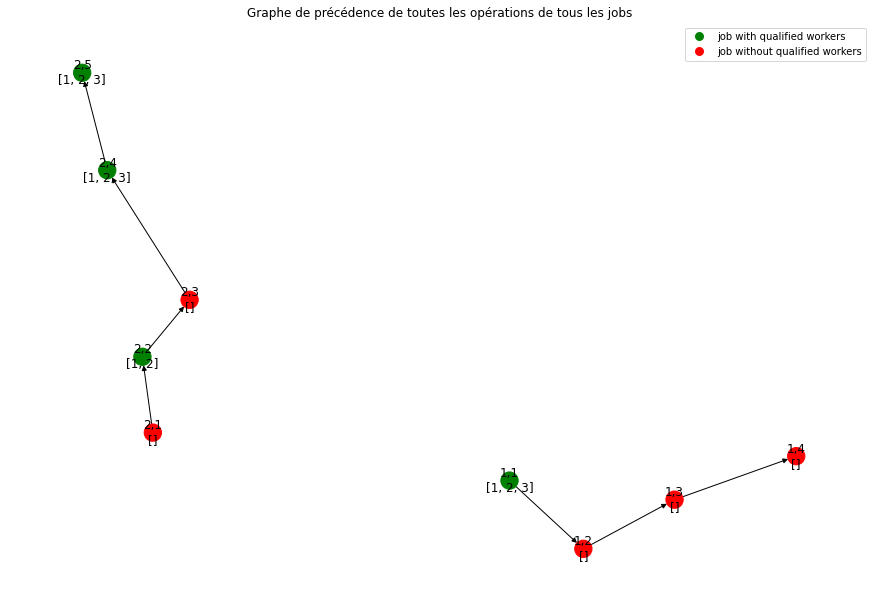

In [35]:
# instance.qualified_workers_for_task(verbose=True)
# instance.feasible_jobs(verbose=True)

visualization_before_scheduling(instance)

### B. Résolution de l'instance

In [36]:
model = Model(instance)
constraints_config = {"constrained_makespan": instance.sum_of_job_alone() / 3}
s = model.solve(objective="benefit", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config=constraints_config)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  34.333333333333336
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: -0.0


<span style="color:red">
- Ne peut être résolu car on autorise pas les workers a faire tache sans niveau
</span>

No tasks to display in the Gantt chart.


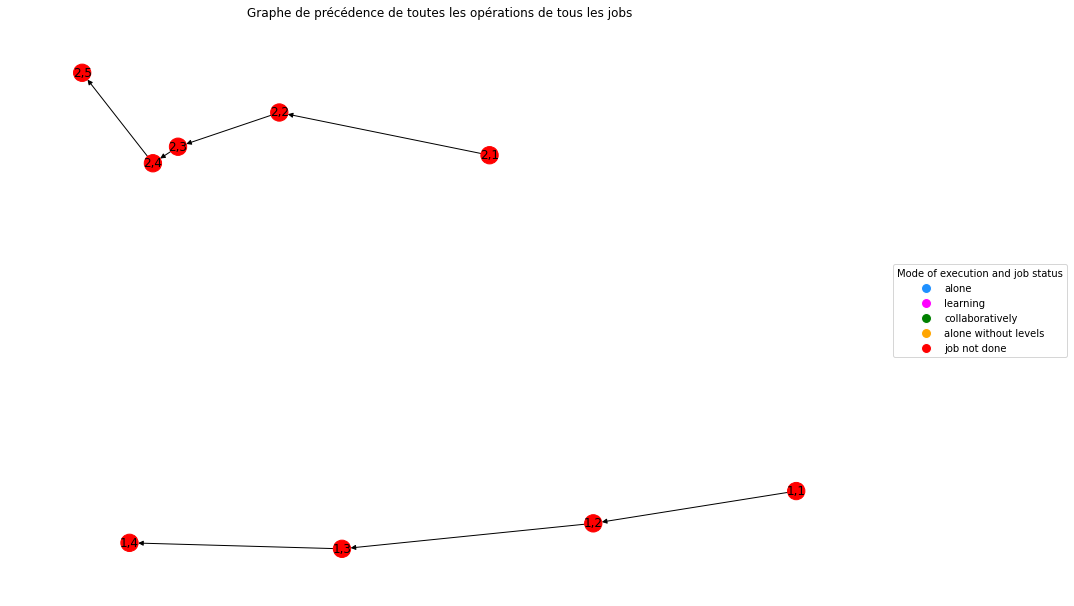

In [37]:
df = scheduling_to_df(s, instance)
gantt_chart(df, render="notebook" , color=3, separate_little=True)
visualization_after_scheduling(instance, s, df)

<span style="color:red">
- On voit bien qu'aucun job n'est réalisé
</span>

### En autorisant les taches sans compétence (au max 1 jobs sans compétences tq difference de niveau en tre tache et worker <= 1)

##### En autorisant un makespan au plus la somme des jobs seuls / 3


 ========== SOLVING MODEL ========== 
job with no skills activated
limite MAKESPAN =  34.333333333333336
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: -0.0
No tasks to display in the Gantt chart.


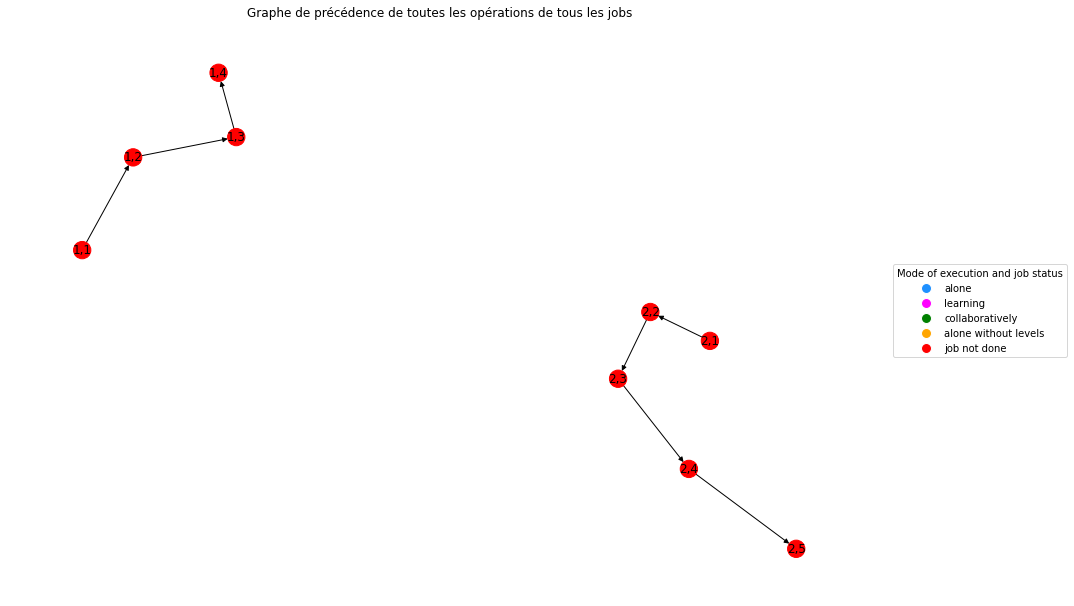

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task


In [38]:
model = Model(instance)
constraints_config = {
                    "constrained_makespan": instance.sum_of_job_alone() / 3,
                    "job_with_no_skills" : True
                    }

s = model.solve(objective="benefit", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config=constraints_config)
df = scheduling_to_df(s, instance)
gantt_chart(df, render="notebook" , color=3, separate_little=True)
visualization_after_scheduling(instance, s, df)
df

##### En autorisant un makespan au plus la somme des jobs seuls / 2

Donc en laissant plus de temps


 ========== SOLVING MODEL ========== 
job with no skills activated
limite MAKESPAN =  51.5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 28.0


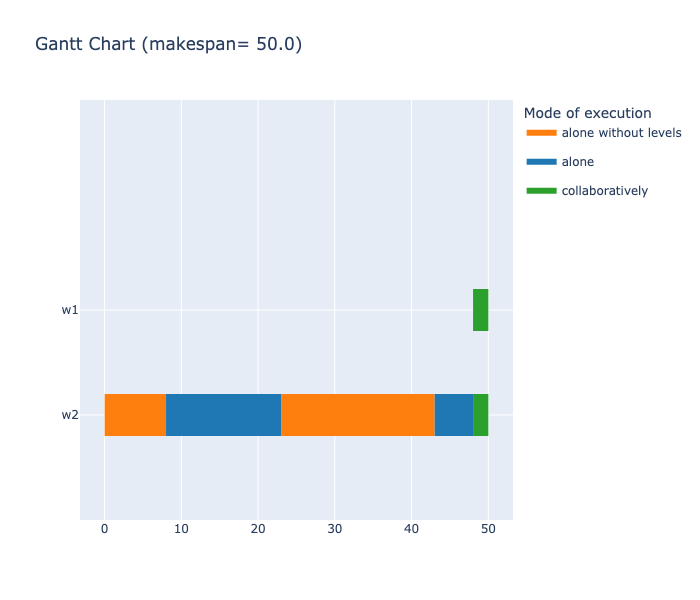

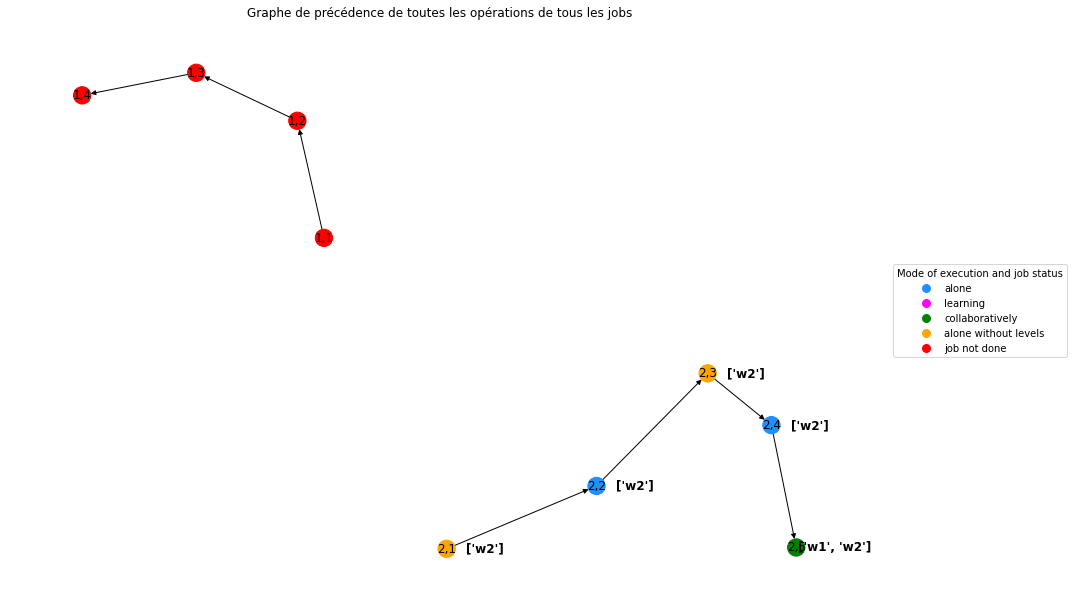

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,48.01,50.0,50.0,2.0,"(2,5)",J2,collaboratively,2.0,2,4.0,1.0
1,w2,0.01,8.0,8.0,8.0,"(2,1)",J2,alone without levels,2.0,3,3.0,1.0
2,w2,8.01,23.0,23.0,15.0,"(2,2)",J2,alone,4.0,2,1.0,0.0
3,w2,23.01,43.0,43.0,20.0,"(2,3)",J2,alone without levels,2.0,3,6.0,2.0
4,w2,43.01,48.0,48.0,5.0,"(2,4)",J2,alone,2.0,2,4.0,1.0
5,w2,48.01,50.0,50.0,2.0,"(2,5)",J2,collaboratively,2.0,2,4.0,1.0


In [39]:
model = Model(instance)
constraints_config = {
                    "constrained_makespan": instance.sum_of_job_alone() / 2,
                    "job_with_no_skills" : True
                    }

s = model.solve(objective="benefit", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config=constraints_config)
df = scheduling_to_df(s, instance)
gantt_chart(df, render="notebook" , color=3, separate_little=True)
visualization_after_scheduling(instance, s, df)
df

<span style="color:red">
- On voit bien que le worker qui a fait les taches avait un niveau de difference de 1 avec les tahces fait sans niveau requis
</span>

Ci dessous on peut voir : 
- Visualisation de la charge cognitifs des workers pour chaque profession
- Visualisation du niveau d'augmentation du level de chaque worker par profession

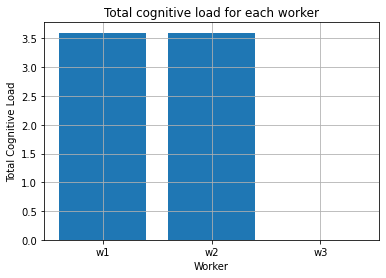

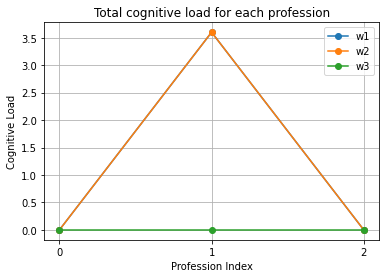

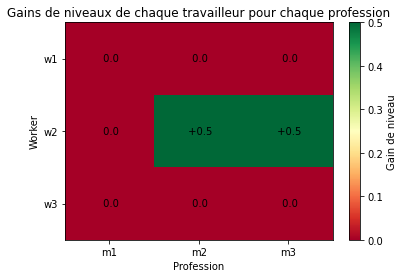

In [44]:
bars_cognitive_load_total(s, instance)
plot_cognitive_load_total(s, instance)
resume_levels_workers(s, instance)

#### Augmentation manuelle du niveau du worker 3 pour faire changer le comportement des affectations du programme

In [45]:
instance_2 = deepcopy(instance)
instance_2.levels_workers

array([[2., 2., 1.],
       [4., 2., 2.],
       [1., 2., 1.]])

In [46]:
instance_2.levels_workers[2][2] += 1.1
instance_2.levels_workers[2][0] += 1

In [47]:
instance_2.levels_workers

array([[2. , 2. , 1. ],
       [4. , 2. , 2. ],
       [2. , 2. , 2.1]])

- Maintenant le le worker $3$ est plus compétent que le worker $2$ sur les taches du métier d'indice 2  et equivalent sur tache du metier 1 donc sera choisit normalement


 ========== SOLVING MODEL ========== 
job with no skills activated
limite MAKESPAN =  51.5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 28.1


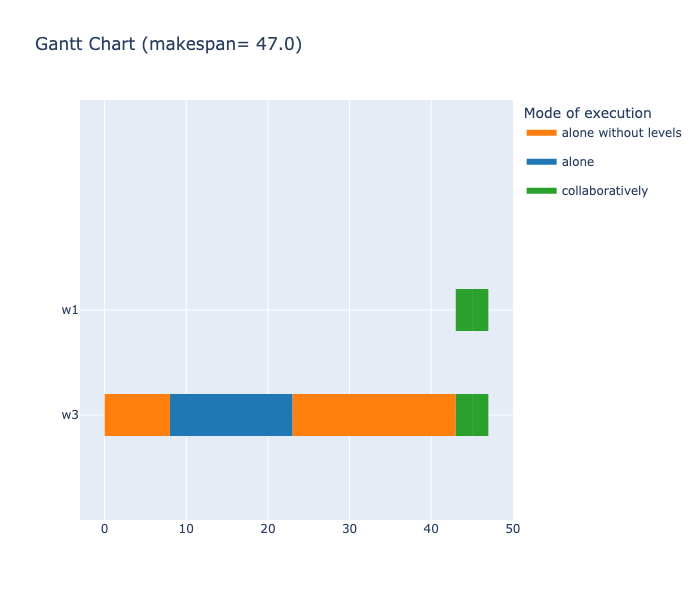

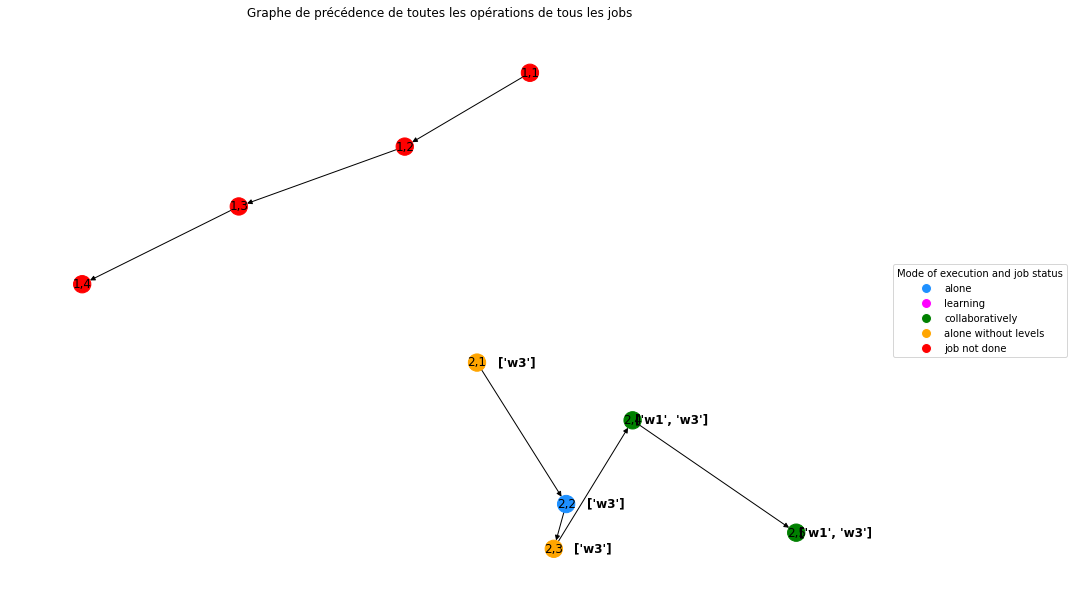

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,43.01,45.0,45.0,2.0,"(2,4)",J2,collaboratively,2.0,2,4.0,1.0
1,w1,45.01,47.0,47.0,2.0,"(2,5)",J2,collaboratively,2.0,2,4.0,1.0
2,w3,0.01,8.0,8.0,8.0,"(2,1)",J2,alone without levels,2.0,3,3.0,1.0
3,w3,8.01,23.0,23.0,15.0,"(2,2)",J2,alone,2.0,2,1.0,0.0
4,w3,23.01,43.0,43.0,20.0,"(2,3)",J2,alone without levels,2.1,3,6.0,2.0
5,w3,43.01,45.0,45.0,2.0,"(2,4)",J2,collaboratively,2.0,2,4.0,1.0
6,w3,45.01,47.0,47.0,2.0,"(2,5)",J2,collaboratively,2.0,2,4.0,1.0


In [48]:
model = Model(instance_2)
constraints_config = {
                    "constrained_makespan": instance_2.sum_of_job_alone() / 2,
                    "job_with_no_skills" : True
                    }

s = model.solve(objective="benefit", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config=constraints_config)
df = scheduling_to_df(s, instance_2)
gantt_chart(df, render="notebook" , color=3, separate_little=True)
visualization_after_scheduling(instance_2, s, df)
df

<span style="color:red">
- L'algorithme a choisit le worker 3 pour faire les taches du job 2
</span>

---

# Approximation du front de Pareto

$\epsilon$ - contraintes :

In [4]:
instance_generated = Instance()
instance_generated.from_random(nb_jobs=7, nb_professions=4, nb_workers=3, max_nb_operations=8, seed=2048)

In [5]:
print(instance_generated)


 ===== Start of Instance: =====
Number of jobs: 7
Number of professions: 4
Number of tasks per profession: [3 3 3 3]
Max number of operations per Jobs: 8
Total number of tasks: 12
Total number of workers: 3
Task to profession mapping:
{0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1, 6: 2, 7: 2, 8: 2, 9: 3, 10: 3, 11: 3}
Worker levels: shape=(3, 4)
 [[1 4 1 3]
 [2 2 3 4]
 [2 4 3 1]]
Job difficulties: shape= (7,)
[4 3 4 4 4 4 4]
Job resale prices: shape= (7,)
[106.61310711  42.38059853  36.61994601 149.62038691  44.15412039
  78.10896574  87.53586769]
Task difficulties: shape= (12,)
[3 3 4 2 4 2 2 3 1 4 1 3]
Task processing times: shape= (12, 3)
[[10.         20.27405348 -1.        ]
 [12.         22.52637836  8.20622659]
 [ 2.          2.89354788  1.65094207]
 [15.         21.72148167  9.62569878]
 [19.         39.48753227 17.4990901 ]
 [ 9.         10.966967    8.23375157]
 [19.         24.35917528 10.94831488]
 [ 8.         11.9807899   7.51372133]
 [ 7.         12.53192602  6.74942231]
 [17.   

In [6]:
instance = instance_generated

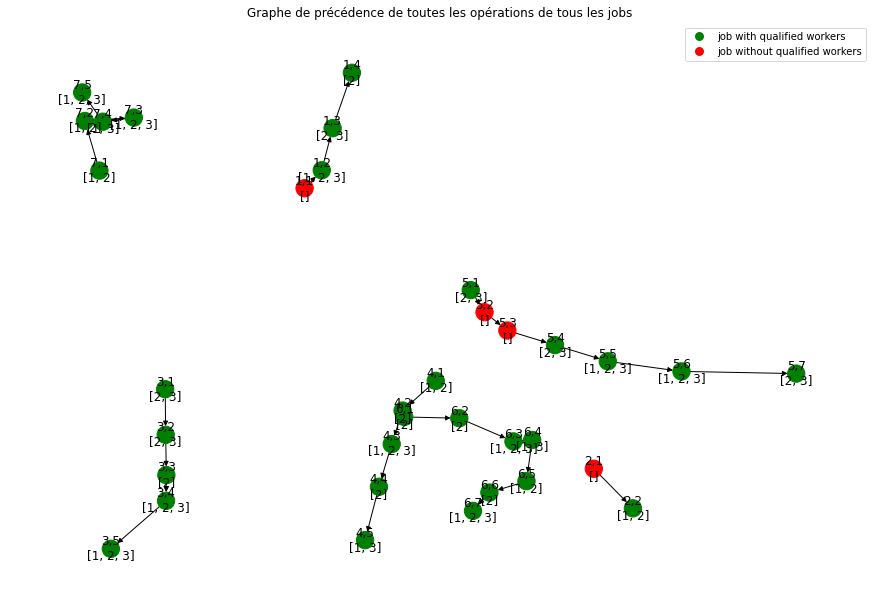

In [7]:
# instance.qualified_workers_for_task(verbose=True)
# instance.feasible_jobs(verbose=True)

visualization_before_scheduling(instance)

In [8]:
print("Temps total des jobs en mode seul :", instance.sum_of_job_alone())
print("Temps moyen d'un job en mode seul :", instance.mean_time_job_alone())
print("Temps moyen d'une opération :", instance.mean_time_operations())

Temps total des jobs en mode seul : 502.0
Temps moyen d'un job en mode seul : 71.71428571428571
Temps moyen d'une opération : 5.0


In [9]:
TIME_LIMIT_MAKESPAN = instance.sum_of_job_alone() / 4
print("temps total laissé pour le scheduling :", TIME_LIMIT_MAKESPAN)

temps total laissé pour le scheduling : 125.5


In [10]:
constraints_config = {"constrained_makespan" : TIME_LIMIT_MAKESPAN}

### A ce moment la cette ligne etait actif dans le code : 

```python
s = self.solve(objective="lexicographic", priority=[2, 1, 0], constraints_config=constraints_config_epsilon, verbose=verbose)
```

In [11]:
model = Model(instance)
x, s = model.epsilon_contraintes(constraints_config=constraints_config,verbose=False)


 ========== SOLVING MODEL ========== 
Set parameter Username


Academic license - for non-commercial use only - expires 2027-01-05
job with no skills desactived
limite MAKESPAN =  125.5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 273.77620061044934

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  125.5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 273.77620061044934

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  125.5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 237.15625459849784

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  125.5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution fo

nombre de solution trouvées:  14
nombre de solution uniques:  5


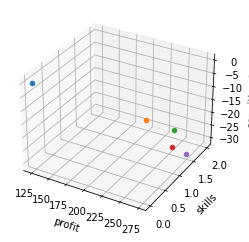

In [28]:
print("nombre de solution trouvées: ", len(x))
x_without_duplicate = np.unique(np.round(x, 5), axis=0)
print("nombre de solution uniques: ", len(x_without_duplicate))

plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("profit")
axes.set_ylabel("skills")
axes.set_zlabel("- cognitive_load")

for i in range(len(x_without_duplicate)):
    axes.scatter(x_without_duplicate[i,0], x_without_duplicate[i,1], x_without_duplicate[i,2], marker="o")
plt.show()

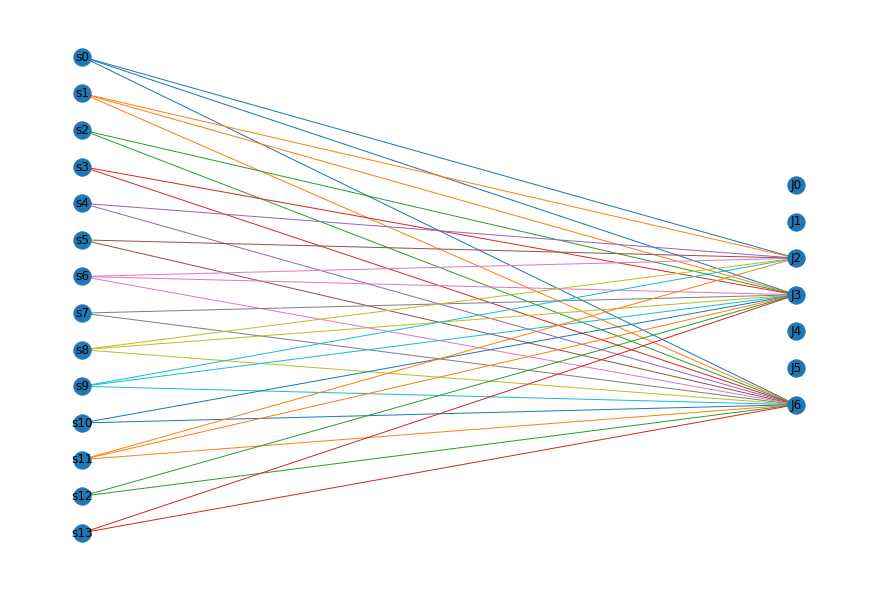

In [43]:
visualization_list_of_solutions(instance, s)

Coordonées des solutions uniques trouvées :

In [13]:
# np.set_printoptions(precision=20)
print(x_without_duplicate)

[[124.15581   0.        0.     ]
 [237.15625   1.      -15.     ]
 [237.15625   2.      -29.2    ]
 [273.7762    1.      -22.2    ]
 [273.7762    1.5     -30.4    ]]


### Test visualisation graphique des jobs

In [17]:
for i in range(len(s)):
    profit, skills, cognitive_load = s[i].objective_values[0], s[i].objective_values[1], s[i].objective_values[2]
    job_done_sol_i = [ int(j*s[i].job_done[j]) for j in range(len(s[i].job_done)) ]
    print(f"index {i}: [{profit:.2f}] [{skills:.2f}] [{cognitive_load:.2f}] \t\t job done: {job_done_sol_i}" )
    print("----------")

index 0: [273.78] [1.50] [-30.40] 		 job done: [0, 0, 2, 3, 0, 0, 6]
----------
index 1: [273.78] [1.00] [-22.20] 		 job done: [0, 0, 2, 3, 0, 0, 6]
----------
index 2: [237.16] [2.00] [-29.20] 		 job done: [0, 0, 0, 3, 0, 0, 6]
----------
index 3: [237.16] [2.00] [-29.20] 		 job done: [0, 0, 0, 3, 0, 0, 6]
----------
index 4: [124.16] [0.00] [0.00] 		 job done: [0, 0, 2, 0, 0, 0, 6]
----------
index 5: [124.16] [0.00] [0.00] 		 job done: [0, 0, 2, 0, 0, 0, 6]
----------
index 6: [273.78] [1.50] [-30.40] 		 job done: [0, 0, 2, 3, 0, 0, 6]
----------
index 7: [237.16] [1.00] [-15.00] 		 job done: [0, 0, 0, 3, 0, 0, 6]
----------
index 8: [273.78] [1.50] [-30.40] 		 job done: [0, 0, 2, 3, 0, 0, 6]
----------
index 9: [273.78] [1.50] [-30.40] 		 job done: [0, 0, 2, 3, 0, 0, 6]
----------
index 10: [237.16] [1.00] [-15.00] 		 job done: [0, 0, 0, 3, 0, 0, 6]
----------
index 11: [273.78] [1.50] [-30.40] 		 job done: [0, 0, 2, 3, 0, 0, 6]
----------
index 12: [237.16] [2.00] [-29.20] 		 job 

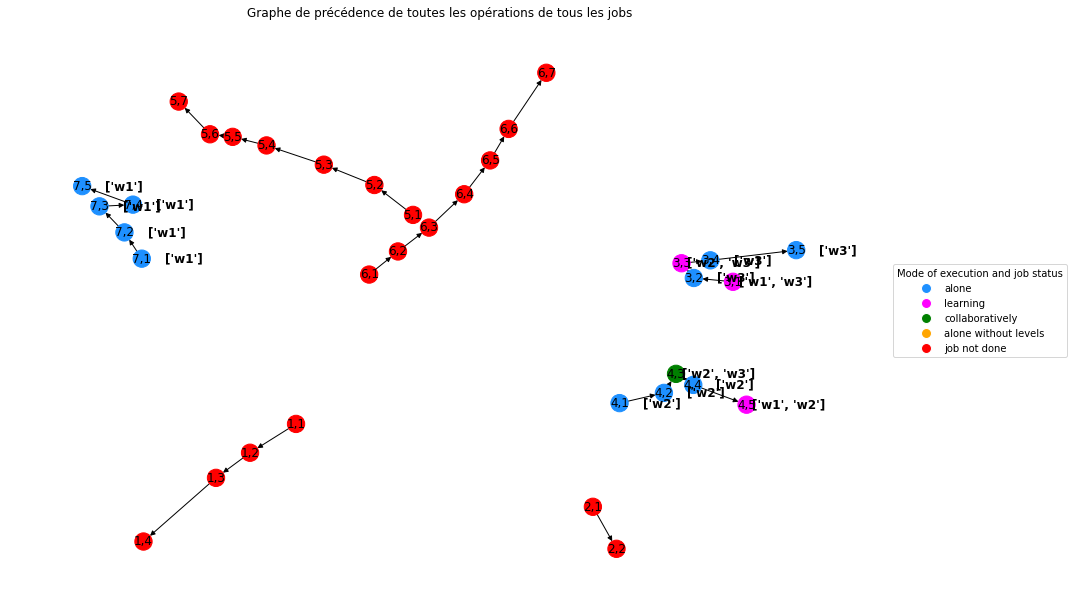

In [18]:
INDEX = 0
sol_curr = s[INDEX]
df = scheduling_to_df(sol_curr, instance)
visualization_after_scheduling(instance, sol_curr, df)

In [30]:
print("Toute les solutions sont non dominées ?: ", check_dominance_pareto(x_without_duplicate))
lorenz_vector = get_lorenz_vector(x_without_duplicate)
lorenz_optimal, idx_lorenz_dominated = get_pareto_optimal(lorenz_vector)
lorenz_optimal[:,0,:]

Toute les solutions sont non dominées ?:  True


array([[124.15581,   0.     ,   0.     ],
       [237.15625,   1.     , -15.     ],
       [273.7762 ,   1.     , -22.2    ]])

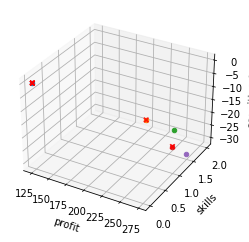

In [20]:
plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("profit")
axes.set_ylabel("skills")
axes.set_zlabel("- cognitive_load")

for i in range(len(x_without_duplicate)):
    axes.scatter(x_without_duplicate[i,0], x_without_duplicate[i,1], x_without_duplicate[i,2], marker="o")
    axes.scatter(lorenz_optimal[:,0, 0], lorenz_optimal[:, 0, 1], lorenz_optimal[:, 0, 2], color="red", marker="x")
plt.show()

## Visualisation 2d pour un profit fixé

In [21]:
idx_profit_233 = np.where(x_without_duplicate[:, 0]>= 273)

In [22]:
new_x = [list (i) for i in x_without_duplicate[idx_profit_233]]
new_x = np.unique(new_x, axis=0)
new_x

array([[273.7762,   1.    , -22.2   ],
       [273.7762,   1.5   , -30.4   ]])

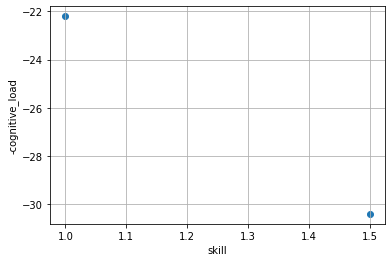

In [25]:
plt.scatter(new_x[:, 1], new_x[:, 2])
plt.xlabel("skill")
plt.ylabel("-cognitive_load")
plt.grid()
plt.show()

### Maintenant on remplace par: 

````python
s = self.solve(objective="benefit", priority=[2, 1, 0], constraints_config=constraints_config_epsilon, verbose=verbose)
````

In [26]:
model = Model(instance)
xMAJ, sMAJ = model.epsilon_contraintes(constraints_config=constraints_config,verbose=False)


 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  125.5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 273.77620061044934

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  125.5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 273.77620061044934

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  125.5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 237.15625459849784

 ========== SOLVING MODEL ========== 
job with no skills desactived
limite MAKESPAN =  125.5
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 237

nombre de solution trouvées:  14
nombre de solution uniques:  9


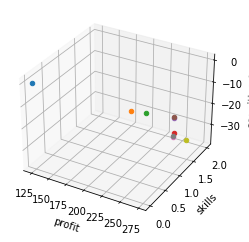

In [29]:
print("nombre de solution trouvées: ", len(xMAJ))
xMAJ_without_duplicate = np.unique(np.round(xMAJ, 5), axis=0)
print("nombre de solution uniques: ", len(xMAJ_without_duplicate))

plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("profit")
axes.set_ylabel("skills")
axes.set_zlabel("- cognitive_load")

for i in range(len(xMAJ_without_duplicate)):
    axes.scatter(xMAJ_without_duplicate[i,0], xMAJ_without_duplicate[i,1], xMAJ_without_duplicate[i,2], marker="o")
plt.show()

In [31]:
print(xMAJ_without_duplicate)

[[124.15581   0.        0.     ]
 [237.15625   0.5      -7.9    ]
 [237.15625   1.      -15.     ]
 [237.15625   2.      -36.8    ]
 [237.15625   2.      -29.9    ]
 [237.15625   2.      -29.2    ]
 [273.7762    1.      -22.6    ]
 [273.7762    1.      -22.2    ]
 [273.7762    1.5     -30.4    ]]


In [34]:
print("Toute les solutions sont non dominées ?: ", check_dominance_pareto(xMAJ_without_duplicate))

Points  3  and  4  are not Pareto optimal.
Toute les solutions sont non dominées ?:  False


In [40]:
xMAJ_non_dominated, idx = get_pareto_optimal(xMAJ_without_duplicate)
print("nombre de solution non dominées: ", len(xMAJ_non_dominated))
print(xMAJ_non_dominated)

nombre de solution non dominées:  5
[[124.15581   0.        0.     ]
 [237.15625   0.5      -7.9    ]
 [237.15625   1.      -15.     ]
 [273.7762    1.      -22.2    ]
 [273.7762    1.5     -30.4    ]]


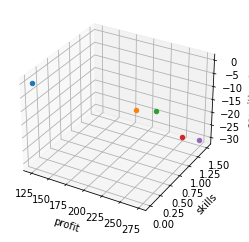

In [41]:
plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("profit")
axes.set_ylabel("skills")
axes.set_zlabel("- cognitive_load")

for i in range(len(xMAJ_non_dominated)):
    axes.scatter(xMAJ_non_dominated[i,0], xMAJ_non_dominated[i,1], xMAJ_non_dominated[i,2], marker="o")
plt.show()

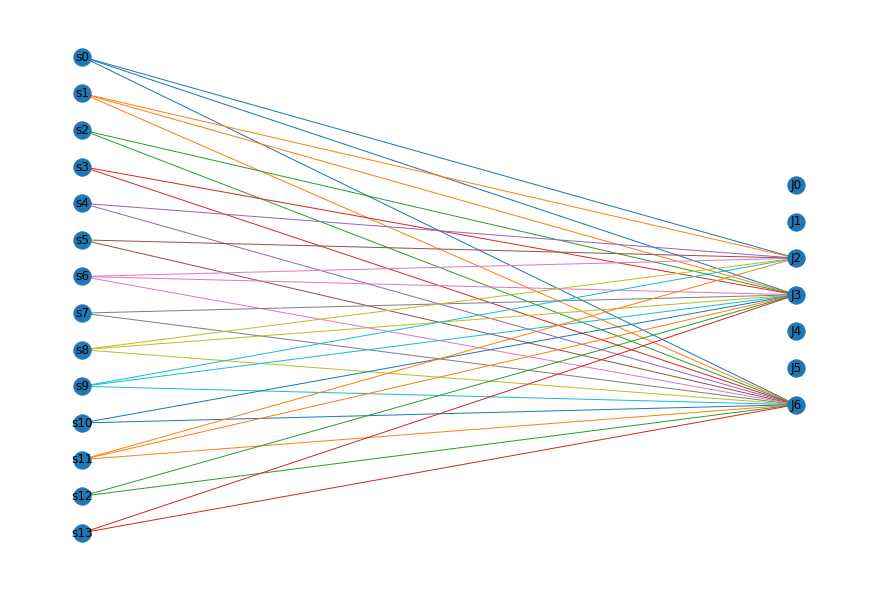

In [45]:
# Ancien avec lexicographique dans eps contrainte
visualization_list_of_solutions(instance, s)

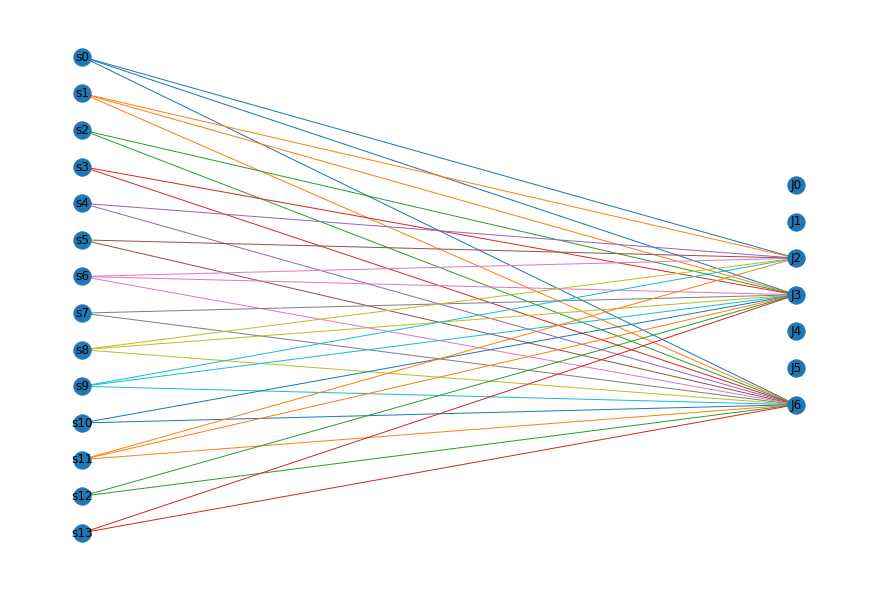

In [44]:
visualization_list_of_solutions(instance, sMAJ)

---
---
---
# Ne pas prendre en compte la suite du notebook
---
---
---

# Instance plus grande

In [4]:
instance_generated = Instance()
instance_generated.from_random(nb_jobs=10, nb_professions=7, nb_workers=4, max_nb_operations=8, at_least_a_worker_have_competence_for_each_profession=False, seed=42)

In [5]:
print(instance_generated)


 ===== Start of Instance: =====
Number of jobs: 10
Number of professions: 7
Number of tasks per profession: [2 3 2 2 2 3 2]
Max number of operations per Jobs: 8
Total number of tasks: 16
Total number of workers: 4
Task to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 2, 6: 2, 7: 3, 8: 3, 9: 4, 10: 4, 11: 5, 12: 5, 13: 5, 14: 6, 15: 6}
Worker levels: shape=(4, 7)
 [[2 3 2 1 4 3 1]
 [4 4 2 1 4 3 3]
 [2 4 1 3 4 4 2]
 [3 3 1 3 1 3 2]]
Job difficulties: shape= (10,)
[4 4 3 4 4 4 4 3 4 4]
Job resale prices: shape= (10,)
[ 36.78115143  67.266124   114.00551891  65.24841048  92.63068704
 118.42265425  70.90814433 117.03711869 154.74262129  55.24952142]
Task difficulties: shape= (16,)
[1 4 1 4 4 4 3 3 3 1 4 3 3 1 3 1]
Task processing times: shape= (16, 3)
[[ 7.          8.72665964  4.30812839]
 [19.         41.30135486 11.78974193]
 [11.         15.76048474  9.25794935]
 [11.         14.19667078  8.85498162]
 [ 4.          7.27354404  3.66638982]
 [ 8.         12.65969593  4.69345861]


In [6]:
model = Model(instance_generated)
constraints_config = {"constrained_makespan" : instance_generated.sum_of_job_alone() / 2}
x, solution_list = model.epsilon_contraintes(constraints_config=constraints_config,verbose=False)


 ========== SOLVING MODEL ========== 
Set parameter Username


Academic license - for non-commercial use only - expires 2027-01-05
job with no skills desactived
BORNE_SUP_MAKESPAN ACTIVATE ->  191.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315

 ========== SOLVING MODEL ========== 
job with no skills desactived
BORNE_SUP_MAKESPAN ACTIVATE ->  191.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315

 ========== SOLVING MODEL ========== 
job with no skills desactived
BORNE_SUP_MAKESPAN ACTIVATE ->  191.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315

 ========== SOLVING MODEL ========== 
job with no skills desactived
BORNE_SUP_MAKESPAN ACTIVATE ->  191.0
Set parameter SolFiles to value "../results/intermediate_solutions

13
3


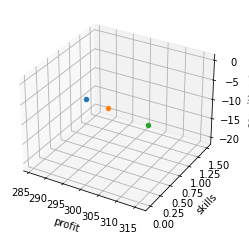

In [7]:
print(len(x))
solution_list_no_duplicate = np.unique(np.round(x, 5), axis=0)
print(len(solution_list_no_duplicate))

plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("profit")
axes.set_ylabel("skills")
axes.set_zlabel("- cognitive_load")

for i in range(len(solution_list_no_duplicate)):
    axes.scatter(solution_list_no_duplicate[i,0], solution_list_no_duplicate[i,1], solution_list_no_duplicate[i,2], marker="o")
plt.show()

In [8]:
model_2 = Model(instance_generated)
constraints_config = {"constrained_makespan" : instance_generated.sum_of_job_alone() / 2, "no_base_worker" : True}
x_2, solution_list_2 = model_2.epsilon_contraintes(constraints_config=constraints_config,verbose=False)


 ========== SOLVING MODEL ========== 
job with no skills desactived
BORNE_SUP_MAKESPAN ACTIVATE ->  191.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315

 ========== SOLVING MODEL ========== 
job with no skills desactived
BORNE_SUP_MAKESPAN ACTIVATE ->  191.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315

 ========== SOLVING MODEL ========== 
job with no skills desactived
BORNE_SUP_MAKESPAN ACTIVATE ->  191.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315

 ========== SOLVING MODEL ========== 
job with no skills desactived
BORNE_SUP_MAKESPAN ACTIVATE ->  191.0
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0

13
3


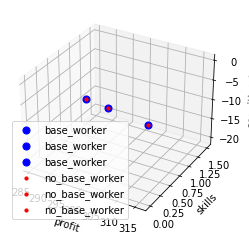

In [19]:
print(len(x_2))
solution_list_no_duplicate_2 = np.unique(np.round(x_2, 5), axis=0)
print(len(solution_list_no_duplicate_2))

plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("profit")
axes.set_ylabel("skills")
axes.set_zlabel("- cognitive_load")

for i in range(len(solution_list_no_duplicate)):
    axes.scatter(solution_list_no_duplicate[i,0], solution_list_no_duplicate[i,1], solution_list_no_duplicate[i,2], marker="o", color="blue", label="base_worker", s=50)

for i in range(len(solution_list_no_duplicate_2)):    
    axes.scatter(solution_list_no_duplicate_2[i,0], solution_list_no_duplicate_2[i,1], solution_list_no_duplicate_2[i,2], marker="o", color="red", label="no_base_worker", s=10)

plt.legend()
plt.show()

In [287]:
model_3 = Model(instance_generated)
constraints_config = {"constrained_makespan" : True, "no_collaboration_tasks" : True}
x_3, solution_list_3 = model_3.epsilon_contraintes(constraints_config=constraints_config,verbose=False)

Born sup makespan: 191.0
job with no skills desactived
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315
job with no skills desactived
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315
job with no skills desactived
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315
job with no skills desactived
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315
job with no skills desactived
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
penalty deadline obj: 0
Optimal solution found with objective value: 300.7081834139315
job with no skills desactived


18
3


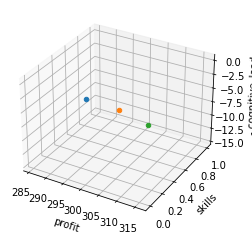

In [288]:
print(len(x_3))
solution_list_no_duplicate_3 = np.unique(np.round(x_3, 5), axis=0)
print(len(solution_list_no_duplicate_3))

plt.figure("Exemple 3D")
axes = plt.axes(projection="3d")
axes.set_xlabel("profit")
axes.set_ylabel("skills")
axes.set_zlabel("- cognitive_load")

for i in range(len(solution_list_no_duplicate_3)):
    axes.scatter(solution_list_no_duplicate_3[i,0], solution_list_no_duplicate_3[i,1], solution_list_no_duplicate_3[i,2], marker="o")
plt.show()

In [289]:
x_3

array([[300.7081834139315  ,   1.               , -14.5              ],
       [300.7081834139315  ,   0.               ,   0.               ],
       [300.7081834139315  ,   1.               , -14.5              ],
       [300.7081834139315  ,   1.               , -14.5              ],
       [300.7081834139315  ,   0.               ,   0.               ],
       [300.7081834139315  ,   0.               ,   0.               ],
       [300.7081834139315  ,   1.               , -14.5              ],
       [300.7081834139315  ,   0.5              ,  -6.700000000000001],
       [300.7081834139315  ,   0.5              ,  -6.7              ],
       [300.7081834139315  ,   0.5              ,  -6.7              ],
       [300.7081834139315  ,   0.               ,  -0.               ],
       [300.7081834139315  ,   0.               ,  -0.               ],
       [300.7081834139315  ,   0.               ,  -0.               ],
       [300.7081834139315  ,   0.               ,  -0.          

In [290]:
solution_list_no_duplicate_3

array([[300.70818,   0.     ,   0.     ],
       [300.70818,   0.5    ,  -6.7    ],
       [300.70818,   1.     , -14.5    ]])

In [20]:
df

NameError: name 'df' is not defined

In [21]:
import gurobipy as gp
from gurobipy import GRB
from utils import *
import numpy as np
import time
from mpl_toolkits.mplot3d import Axes3D
from tqdm import tqdm

from Instance import *
from Solution import *
from Constante import *
from first_model import *

print("======== INSTANCE ========")
# res = read_file("../data/data_resale_price_simple.test")
res = read_file("../data/data_resale_price_1.test")
instance = Instance()
instance.from_dictionary(res)

print(instance.sum_of_job_alone())
print(instance)
print(instance.qualified_workers_for_task(verbose=True))
print(instance.feasible_jobs())

print("======== MODEL ========")
model = Model(instance)


print("======== CONFIG ========")
constraints_config = {"constrained_makespan": instance.sum_of_job_alone() /2,
                      "job_with_no_skills": True }

# de base : 
# - worker de base 
# - pas le droit de fair une opération sans level requis


print("======== SOLVE ========")
# s = model.solve(objective="lexicographic", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)
s = model.solve(objective="benefit", weight=[0, 0, 0], priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)


print("======== RESULTS ========")
df = scheduling_to_df(s, instance)
gantt_chart(df, render="html", separate_little=True, color=3)
print(df)
print(check_df(df))
print(s.all_jobs_completed())
print(s.which_jobs_are_completed())
print(s.penalty_makespan)
print(s)


print("======= VISUALIZATION ========")
# resume_levels_workers(s, instance, verbose=True)
# bars_cognitive_load_total(s, instance, verbose=True)
# plot_cognitive_load_total(s, instance)

# TESTING DF FUNCTION
print(df.groupby("Operation"))


## NEW FUNCTION IN ELABORATION
# visualization_before_scheduling(instance)
# visualization_after_scheduling(instance, s, df)

======== INSTANCE ========
103.0

 ===== Start of Instance: =====
Number of jobs: 2
Number of professions: 3
Number of tasks per profession: [2. 4. 1.]
Max number of operations per Jobs: 5
Total number of tasks: 7
Total number of workers: 3
Task to profession mapping:
{0: 0, 1: 0, 2: 1, 3: 1, 4: 1, 5: 1, 6: 2}
Worker levels: shape=(3, 3)
 [[2. 2. 1.]
 [4. 2. 2.]
 [1. 2. 1.]]
Job difficulties: shape= (2,)
[3. 3.]
Job resale prices: shape= (2,)
[20. 30.]
Task difficulties: shape= (7,)
[1 2 3 3 2 2 3]
Task processing times: shape= (7, 3)
[[ 50. 100.  -1.]
 [ 15.  21.  -1.]
 [  5.   8.   2.]
 [  4.   6.   2.]
 [  5.  10.   2.]
 [  4.  11.   2.]
 [ 10.  20.   2.]]
Jobs structure: len= 2
Job 0 : 	O_(0,0) = 0 	O_(0,1) = 2 	O_(0,2) = 3 	O_(0,3) = 2 
Job 1 : 	O_(1,0) = 3 	O_(1,1) = 1 	O_(1,2) = 6 	O_(1,3) = 4 	O_(1,4) = 4 


 ===== End of Instance: =====

 ========== Qualified workers for each task: ==========
J1:  (1,1): [1, 2, 3] 	 (1,2): [] 	 (1,3): [] 	 (1,4): [] 	

J2:  (2,1): [] 	 (2,2): 

In [22]:
df

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,43.01,45.0,45.0,2.0,"(2,4)",J2,collaboratively,2.0,2,4.0,1.0
1,w2,0.01,8.0,8.0,8.0,"(2,1)",J2,alone without levels,2.0,3,3.0,1.0
2,w2,8.01,23.0,23.0,15.0,"(2,2)",J2,alone,4.0,2,1.0,0.0
3,w2,23.01,43.0,43.0,20.0,"(2,3)",J2,alone without levels,2.0,3,6.0,2.0
4,w2,43.01,45.0,45.0,2.0,"(2,4)",J2,collaboratively,2.0,2,4.0,1.0
5,w2,45.01,50.0,50.0,5.0,"(2,5)",J2,alone,2.0,2,4.0,1.0


In [92]:
# x = df.groupby(["Operation", "mode"]).first()
x = df.groupby(["Operation", "mode", "Task"])
x.first()

Start  Finish  Finish (var. f)  \
Operation mode                 Task                                   
(2,1)     alone without levels w2     0.01     8.0              8.0   
(2,2)     alone                w2     8.01    23.0             23.0   
(2,3)     alone without levels w2    23.01    43.0             43.0   
(2,4)     collaboratively      w1    43.01    45.0             45.0   
                               w2    43.01    45.0             45.0   
(2,5)     alone                w2    45.01    50.0             50.0   

                                     Processing time Job  Level_w  \
Operation mode                 Task                                 
(2,1)     alone without levels w2                8.0  J2      2.0   
(2,2)     alone                w2               15.0  J2      4.0   
(2,3)     alone without levels w2               20.0  J2      2.0   
(2,4)     collaboratively      w1                2.0  J2      2.0   
                               w2                2.0  J2      2.0   
(2,5)     alone                w2                5.0  J2      2.0   

                                     Difficulty_task  Elementary task  Metier  
Operation mode                 Task                                            
(2,1)     alone without levels w2                  3              3.0     1.0  
(2,2)     alone                w2                  2              1.0     0.0  
(2,3)     alone without levels w2                  3              6.0     2.0  
(2,4)     collaboratively      w1                  2              4.0     1.0  
                               w2                  2              4.0     1.0  
(2,5)     alone                w2                  2              4.0     1.0

In [95]:
for (op, mode, w), group_data in x:
    print("op=",op)
    print("mode=",mode)
    print("w=",w)
    print("group_data=",group_data)
    print("-----")
    for i, row in group_data.iterrows():
        print("deb=",row["Operation"], "=fin")
        print("beg=",row["Task"], "=end")

op= (2,1)
mode= alone without levels
w= w2
group_data=   Task  Start  Finish  Finish (var. f)  Processing time Operation Job  \
1   w2   0.01     8.0              8.0              8.0     (2,1)  J2   

                   mode  Level_w Difficulty_task  Elementary task  Metier  
1  alone without levels      2.0               3              3.0     1.0  
-----
deb= (2,1) =fin
beg= w2 =end
op= (2,2)
mode= alone
w= w2
group_data=   Task  Start  Finish  Finish (var. f)  Processing time Operation Job   mode  \
2   w2   8.01    23.0             23.0             15.0     (2,2)  J2  alone   

   Level_w Difficulty_task  Elementary task  Metier  
2      4.0               2              1.0     0.0  
-----
deb= (2,2) =fin
beg= w2 =end
op= (2,3)
mode= alone without levels
w= w2
group_data=   Task  Start  Finish  Finish (var. f)  Processing time Operation Job  \
3   w2  23.01    43.0             43.0             20.0     (2,3)  J2   

                   mode  Level_w Difficulty_task  Elementary task

In [149]:
df

,Task,Start,Finish,Finish (var. f),Processing time,Operation,Job,mode,Level_w,Difficulty_task,Elementary task,Metier
0,w1,43.01,45.0,45.0,2.0,"(2,4)",J2,collaboratively,2.0,2,4.0,1.0
1,w2,0.01,8.0,8.0,8.0,"(2,1)",J2,alone without levels,2.0,3,3.0,1.0
2,w2,8.01,23.0,23.0,15.0,"(2,2)",J2,alone,4.0,2,1.0,0.0
3,w2,23.01,43.0,43.0,20.0,"(2,3)",J2,alone without levels,2.0,3,6.0,2.0
4,w2,43.01,45.0,45.0,2.0,"(2,4)",J2,collaboratively,2.0,2,4.0,1.0
5,w2,45.01,50.0,50.0,5.0,"(2,5)",J2,alone,2.0,2,4.0,1.0


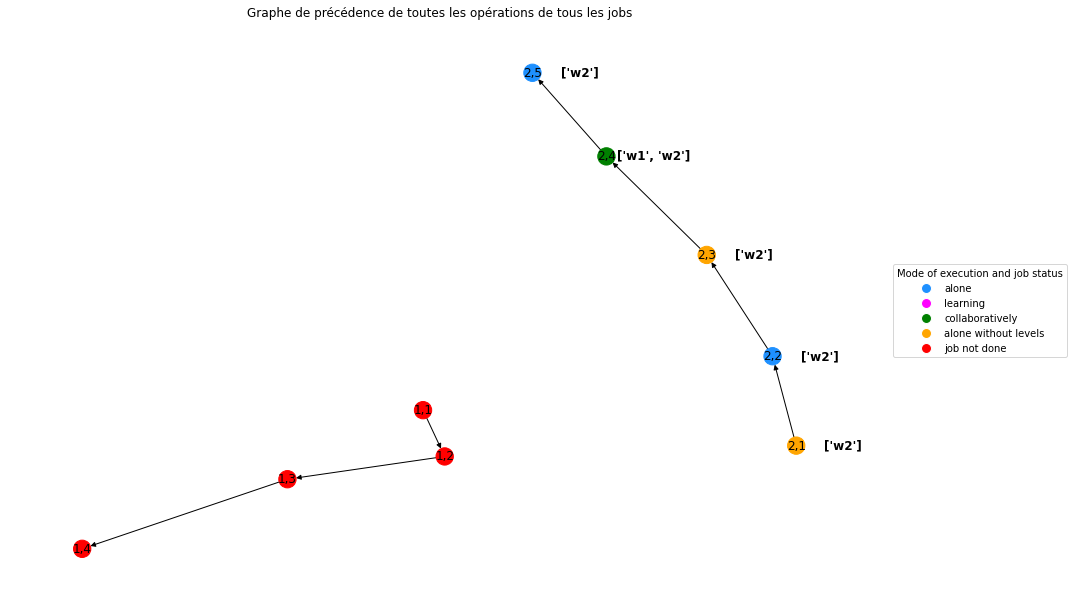

In [188]:
visualization_after_scheduling(instance, s, df)

In [147]:
result = (
    df[["Operation", "mode", "Task"]]
    .groupby(["Operation"])
    .agg({
        "mode": "first", # prendre le premier mode d'execution pour chaque operation (identique une opération)
        "Task": list
    })
).reset_index()

In [148]:
print(result)

  Operation                  mode      Task
0     (2,1)  alone without levels      [w2]
1     (2,2)                 alone      [w2]
2     (2,3)  alone without levels      [w2]
3     (2,4)       collaboratively  [w1, w2]
4     (2,5)                 alone      [w2]


In [152]:
for i in range(len(result)):
    print(f"Operation: {result.loc[i, 'Operation']}, Mode: {result.loc[i, 'mode']}, Tasks: {result.loc[i, 'Task']}")

Operation: (2,1), Mode: alone without levels, Tasks: ['w2']
Operation: (2,2), Mode: alone, Tasks: ['w2']
Operation: (2,3), Mode: alone without levels, Tasks: ['w2']
Operation: (2,4), Mode: collaboratively, Tasks: ['w1', 'w2']
Operation: (2,5), Mode: alone, Tasks: ['w2']


In [134]:
list(df3)

[array(['w2'], dtype=object),
 array(['w2'], dtype=object),
 array(['w2'], dtype=object),
 array(['w1', 'w2'], dtype=object),
 array(['w2'], dtype=object)]

In [136]:
df2.groupby(["Operation"]).first()

,mode,Task
Operation,,
"(2,1)",alone without levels,w2
"(2,2)",alone,w2
"(2,3)",alone without levels,w2
"(2,4)",collaboratively,w1
"(2,5)",alone,w2


In [129]:
for (op, mode), group_data in df3:
    print("op=",op)
    print("mode=",mode)
    print("w=",w)
    print("group_data=",group_data)
    print("-----")

ValueError: not enough values to unpack (expected 2, got 1)